# Studi Kasus Mandiri 1 — Eksplorasi Data Produksi Harian Pabrik
Pada tahap ini, kita akan memuat dataset operasional harian pabrik ke dalam DataFrame pandas untuk mulai melakukan eksplorasi data awal.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Memuat dataset produksi pabrik
df = pd.read_csv('factory_production.csv')
df.head(10)

,Tanggal,Shift,Mesin,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
0,2025-11-01,Pagi,A,376,6,9.9,80.3,55.3
1,2025-11-01,Pagi,B,351,4,54.4,82.1,35.4
2,2025-11-01,Pagi,C,395,8,2.0,72.8,55.2
3,2025-11-01,Pagi,D,466,6,20.3,70.4,54.6
4,2025-11-01,Siang,A,339,3,3.2,70.0,51.9
5,2025-11-01,Siang,B,224,2,11.6,79.4,49.9
6,2025-11-01,Siang,C,294,8,5.7,85.7,68.4
7,2025-11-01,Siang,D,353,10,4.6,80.6,46.7
8,2025-11-01,Malam,A,254,10,10.0,91.1,59.6
9,2025-11-01,Malam,B,231,6,1.8,79.4,63.9


Selanjutnya, kita melakukan inspeksi menyeluruh untuk memahami struktur dataset, tipe data, ukuran statistik deskriptif, serta mendeteksi keberadaan missing value pada setiap kolom.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tanggal           1080 non-null   str    
 1   Shift             1080 non-null   str    
 2   Mesin             1080 non-null   str    
 3   Jumlah_Produksi   1080 non-null   int64  
 4   Jumlah_Cacat      1080 non-null   int64  
 5   Downtime (menit)  1059 non-null   float64
 6   Suhu_Mesin        1048 non-null   float64
 7   Kelembaban        1037 non-null   float64
dtypes: float64(3), int64(2), str(3)
memory usage: 84.2 KB


In [7]:
df.describe()

,Jumlah_Produksi,Jumlah_Cacat,Downtime (menit),Suhu_Mesin,Kelembaban
count,1080.000000,1080.000000,1059.000000,1048.000000,1037.000000
mean,349.600000,7.934259,15.110009,76.951718,49.857281
std,59.510571,4.416073,15.214485,8.218287,10.178976
min,142.000000,0.000000,0.000000,55.000000,25.000000
25%,311.000000,5.000000,4.300000,70.900000,42.900000
50%,349.000000,7.000000,10.800000,77.100000,49.900000
75%,390.250000,10.000000,20.200000,82.500000,56.800000
max,528.000000,42.000000,110.300000,104.900000,79.200000


In [8]:
df.isnull().sum()

Tanggal              0
Shift                0
Mesin                0
Jumlah_Produksi      0
Jumlah_Cacat         0
Downtime (menit)    21
Suhu_Mesin          32
Kelembaban          43
dtype: int64

In [11]:
df_clean = df.copy()

In [12]:
# Imputasi missing value dengan nilai median pada kolom numerik terkait
df_clean['Downtime (menit)'] = df_clean['Downtime (menit)'].fillna(df_clean['Downtime (menit)'].median())
df_clean['Suhu_Mesin'] = df_clean['Suhu_Mesin'].fillna(df_clean['Suhu_Mesin'].median())
df_clean['Kelembaban'] = df_clean['Kelembaban'].fillna(df_clean['Kelembaban'].median())

In [13]:
# Verifikasi ulang untuk memastikan data sudah bersih
df_clean.isnull().sum()

Tanggal             0
Shift               0
Mesin               0
Jumlah_Produksi     0
Jumlah_Cacat        0
Downtime (menit)    0
Suhu_Mesin          0
Kelembaban          0
dtype: int64

**Alasan Penanganan Missing Value:**
Metode imputasi menggunakan nilai median dipilih untuk mengisi data kosong pada kolom *Downtime (menit)*, *Suhu_Mesin*, dan *Kelembaban* agar ukuran baris dataset asli tetap utuh dan informasi produksi penting lainnya pada baris tersebut tidak terbuang sia-sia. Nilai median digunakan karena sifat statistiknya yang jauh lebih kebal (*robust*) terhadap pengaruh nilai ekstrem atau pencilan (*outlier*) dibandingkan rata-rata (*mean*), mengingat variabel operasional pabrik sangat rentan mengalami lonjakan ekstrem saat terjadi gangguan di lantai produksi.

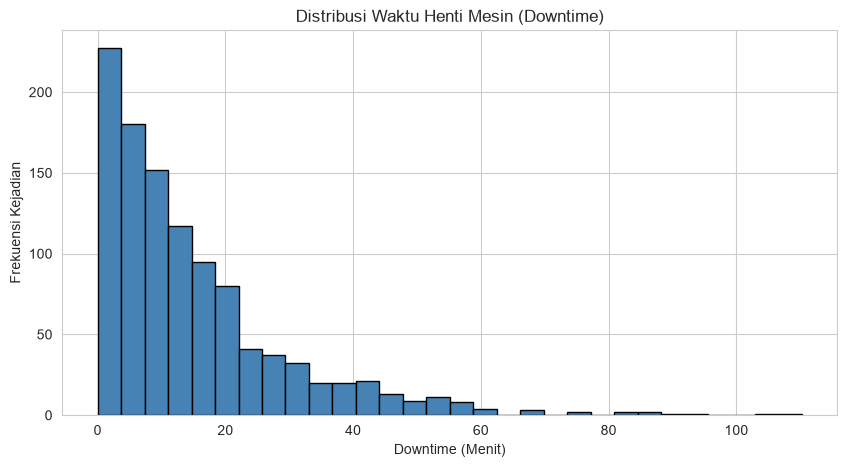

In [14]:
plt.figure(figsize=(10, 5))
df_clean['Downtime (menit)'].hist(bins=30, color='steelblue', edgecolor='black')
plt.title('Distribusi Waktu Henti Mesin (Downtime)')
plt.xlabel('Downtime (Menit)')
plt.ylabel('Frekuensi Kejadian')
plt.show()

**Insight Visualisasi 1:**
Sebagian besar kejadian downtime di pabrik terjadi dalam rentang waktu yang singkat, yaitu antara 0 hingga 20 menit. Namun, terdapat beberapa kasus ekstrem dengan durasi downtime yang melebihi 60 menit, yang membuat distribusi data menjadi miring ke kanan (*right-skewed*). Hal ini menunjukkan bahwa gangguan mesin umumnya dapat diatasi dengan cepat, tetapi kasus langka berdurasi panjang tetap memerlukan perhatian khusus.

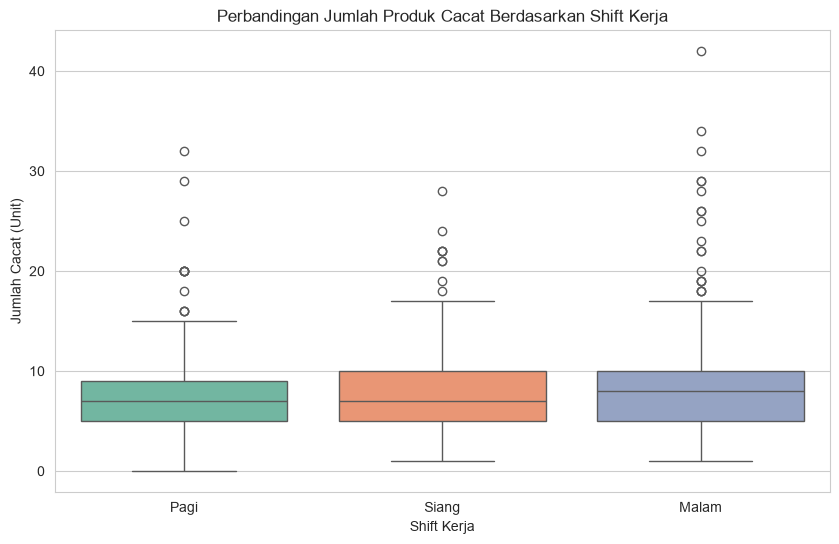

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='Shift', y='Jumlah_Cacat', hue='Shift', palette='Set2', legend=False)
plt.title('Perbandingan Jumlah Produk Cacat Berdasarkan Shift Kerja')
plt.xlabel('Shift Kerja')
plt.ylabel('Jumlah Cacat (Unit)')
plt.show()

**Insight Visualisasi 2:**
Median jumlah produk cacat pada ketiga shift kerja relatif tidak berbeda jauh, namun shift malam memiliki rentang sebaran data dan jumlah *outlier* yang lebih banyak dengan tingkat kecacatan mencapai lebih dari 40 unit. Hal ini mengindikasikan bahwa proses produksi pada shift malam memiliki variasi yang lebih tinggi serta risiko kualitas produk yang lebih rentan dibandingkan shift pagi maupun siang.

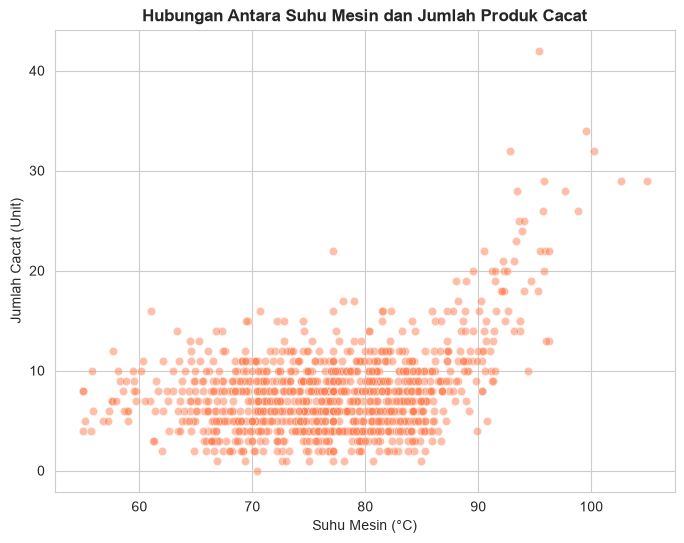

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['Suhu_Mesin'], df_clean['Jumlah_Cacat'], alpha=0.5, color='coral', edgecolor='white', linewidth=0.5)
plt.title('Hubungan Antara Suhu Mesin dan Jumlah Produk Cacat', fontsize=12, fontweight='bold')
plt.xlabel('Suhu Mesin (°C)')
plt.ylabel('Jumlah Cacat (Unit)')
plt.show()

**Insight Visualisasi 3:**
Grafik pencar menunjukkan adanya kecenderungan hubungan positif antara suhu mesin dan jumlah produk cacat, di mana peningkatan suhu — khususnya di atas 90°C — diikuti oleh lonjakan jumlah unit produk yang cacat. Temuan ini menegaskan bahwa kestabilan suhu operasional mesin memegang peranan krusial dalam menjaga kualitas hasil produksi pabrik.